# Training Deep Neural Networks (Tiếp)
Trong buổi này, chúng ta tiếp tục làm quen với một số kỹ thuật huấn luyện mạng nơ-ron

In [1]:
!nvidia-smi
# from google.colab import drive
# drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import glob
import cv2
import torch.nn.functional as F
from torch.autograd import Variable

import torchvision
import torchvision.transforms as transforms

from torch.nn import CrossEntropyLoss, Dropout, Softmax, Linear, Conv2d, LayerNorm
import matplotlib.pyplot as plt
from torchsummary import summary

Fri Oct 17 05:48:54 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.24                 Driver Version: 566.24         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   46C    P5              8W /   80W |    1828MiB /   8188MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 1. Cài đặt BatchNorm

In [2]:
def compare_bn(bn1, bn2): 
    err = False
    if not torch.allclose(bn1.running_mean, bn2.running_mean):
        print('Diff in running_mean: {} vs {}'.format(
            bn1.running_mean, bn2.running_mean))
        err = True

    if not torch.allclose(bn1.running_var, bn2.running_var):
        print('Diff in running_var: {} vs {}'.format(
            bn1.running_var, bn2.running_var))
        err = True

    if bn1.affine and bn2.affine:
        if not torch.allclose(bn1.weight, bn2.weight):
            print('Diff in weight: {} vs {}'.format(
                bn1.weight, bn2.weight))
            err = True

        if not torch.allclose(bn1.bias, bn2.bias):
            print('Diff in bias: {} vs {}'.format(
                bn1.bias, bn2.bias))
            err = True

    if not err:
        print('All parameters are equal!')


class MyBatchNorm2d(nn.BatchNorm2d):
    def __init__(self, num_features, eps=1e-5, momentum=0.1,
                 affine=True, track_running_stats=True):
        super(MyBatchNorm2d, self).__init__(
            num_features, eps, momentum, affine, track_running_stats)

    def forward(self, input):
        self._check_input_dim(input)

        exponential_average_factor = 0.0

        if self.training and self.track_running_stats:
            if self.num_batches_tracked is not None:
                self.num_batches_tracked += 1
                if self.momentum is None:  # use cumulative moving average
                    exponential_average_factor = 1.0 / float(self.num_batches_tracked)
                else:  # use exponential moving average
                    exponential_average_factor = self.momentum

        # calculate running estimates
        if self.training:
            mean = input.mean([0, 2, 3])
            # use biased var in train
            var = input.var([0, 2, 3], unbiased=False)
            n = input.numel() / input.size(1)
            
            with torch.no_grad():
                self.running_mean = exponential_average_factor * mean\
                    + (1 - exponential_average_factor) * self.running_mean
                # update running_var with unbiased var
                self.running_var = exponential_average_factor * var * n / (n - 1)\
                    + (1 - exponential_average_factor) * self.running_var
        else:
            mean = self.running_mean
            var = self.running_var

        mean = mean.view(1, -1, 1, 1)              # broadcast theo N,H,W
        var  = var.view(1, -1, 1, 1)
        
        # Chuẩn hoá input
        input = (input - mean) / torch.sqrt(var + self.eps)
        
        if self.affine:
            # Biến đổi input sau khi chuẩn hoá
            weight = self.weight.view(1, -1, 1, 1)
            bias = self.bias.view(1, -1, 1, 1)
            input = input * weight + bias

        return input


# Init BatchNorm layers
my_bn = MyBatchNorm2d(3, affine=True)
bn = nn.BatchNorm2d(3, affine=True)

compare_bn(my_bn, bn)  # weight and bias should be different
# Load weight and bias
my_bn.load_state_dict(bn.state_dict())
compare_bn(my_bn, bn)

# Run train
for _ in range(10):
    scale = torch.randint(1, 10, (1,)).float()
    bias = torch.randint(-10, 10, (1,)).float()
    x = torch.randn(10, 3, 100, 100) * scale + bias
    out1 = my_bn(x)
    out2 = bn(x)
    compare_bn(my_bn, bn)

    torch.allclose(out1, out2)
    print('Max diff: ', (out1 - out2).abs().max())

# Run eval
my_bn.eval()
bn.eval()
for _ in range(10):
    scale = torch.randint(1, 10, (1,)).float()
    bias = torch.randint(-10, 10, (1,)).float()
    x = torch.randn(10, 3, 100, 100) * scale + bias
    out1 = my_bn(x)
    out2 = bn(x)
    compare_bn(my_bn, bn)

    torch.allclose(out1, out2)

All parameters are equal!
All parameters are equal!
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(7.1526e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(9.5367e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(7.1526e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(9.5367e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(9.5367e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(9.5367e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(7.1526e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
All parameters are equal!
All parameters are equal!
All parameters are equal!
All parameters are equal!
All parameters are

### 2. Cài đặt chiến lược thay đổi tốc độ học: Warm-up + Cosine Annealing LR

In [3]:
def load_data(data_dir="./data"):
    transform = transforms.Compose([
        transforms.ToTensor(),                            
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    trainset = torchvision.datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=transform)

    testset = torchvision.datasets.CIFAR10(
        root=data_dir, train=False, download=True, transform=transform)

    return trainset, testset

class Net(nn.Module):
    def __init__(self, l1=120, l2=84):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, l1)
        self.fc2 = nn.Linear(l1, l2)
        self.fc3 = nn.Linear(l2, 10)
        self.softmax = nn.Softmax()

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        x = self.softmax(x)

        return x

In [4]:
trainset, testset = load_data('./data')
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
)

epochs = 50
warm_epoch = 5
init_lr = 1e-1
last_lr = 1e-5
T_max = epochs
T_cur = 2
lr_list = [0]

net = Net()
device = "cpu"
if torch.cuda.is_available():
    device = "cuda:0"
    if torch.cuda.device_count() > 1:
        net = nn.DataParallel(net)
net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=init_lr, momentum=0.9)

Files already downloaded and verified
Files already downloaded and verified


In [5]:
# 1) Warm-up tuyến tính: scale LR từ start_factor * lr_max -> lr_max trong warmup_epochs
warmup = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=init_lr, total_iters=warm_epoch
)

# 2) Cosine Annealing with Restarts
cosine_restarts = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=T_max, T_mult=T_cur, eta_min=last_lr
)

# 3) Ghép lịch: [warmup] rồi [cosine_restarts]
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup, cosine_restarts],
    milestones=[warm_epoch]
)

In [6]:
for epoch in range(1, epochs+1):  # loop over the dataset multiple times
    running_loss = 0.0
    epoch_steps = 0
    T_cur += 1

    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        epoch_steps += 1
        if i + 1 == len(trainloader):
            print("[Epoch %d] loss: %.3f" % (epoch, running_loss / epoch_steps))
            running_loss = 0.0
            
    scheduler.step()
    lr_list.append(optimizer.param_groups[0]['lr'])
    print('Learning rate: ', optimizer.param_groups[0]['lr'])

print("Finished Training")

c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


[Epoch 1] loss: 2.302
Learning rate:  0.028000000000000004
[Epoch 2] loss: 2.270
Learning rate:  0.046000000000000006
[Epoch 3] loss: 2.159
Learning rate:  0.064
[Epoch 4] loss: 2.090
Learning rate:  0.082
[Epoch 5] loss: 2.087
Learning rate:  0.1
[Epoch 6] loss: 2.240
Learning rate:  0.09990134628777145
[Epoch 7] loss: 2.361
Learning rate:  0.09960577449221733
[Epoch 8] loss: 2.361
Learning rate:  0.0991144511001808
[Epoch 9] loss: 2.361
Learning rate:  0.09842931514062592
[Epoch 10] loss: 2.361
Learning rate:  0.09755307053217621
[Epoch 11] loss: 2.361
Learning rate:  0.09648917541198312
[Epoch 12] loss: 2.361
Learning rate:  0.09524182848803865
[Epoch 13] loss: 2.361
Learning rate:  0.09381595246879296
[Epoch 14] loss: 2.361
Learning rate:  0.09221717463547324
[Epoch 15] loss: 2.361
Learning rate:  0.0904518046337755
[Epoch 16] loss: 2.361
Learning rate:  0.08852680957257558
[Epoch 17] loss: 2.361
Learning rate:  0.08644978652793348
[Epoch 18] loss: 2.361
Learning rate:  0.084228932

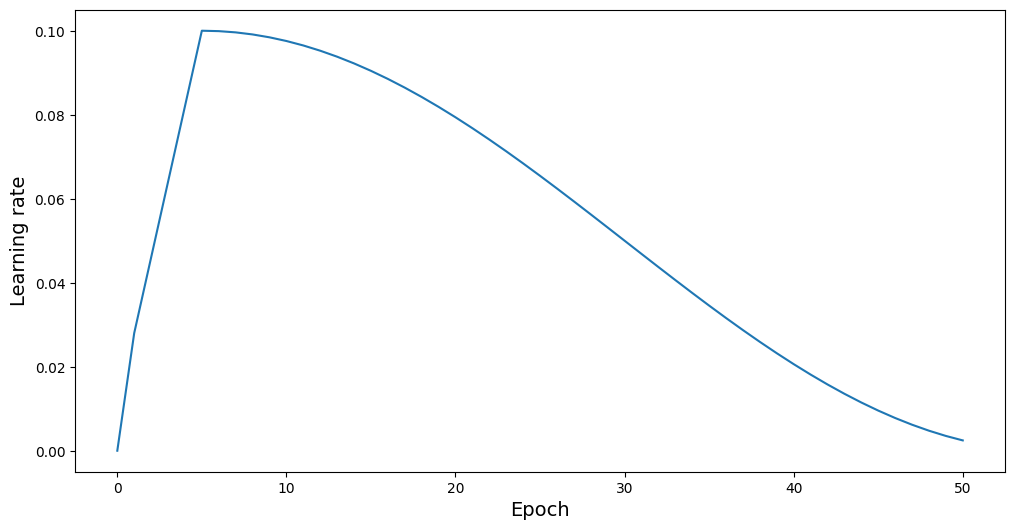

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(list(range(len(lr_list))), lr_list, label="lr")
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Learning rate", fontsize=14)
plt.show()

### 3. Tuning siêu tham số

Cài đặt thư viện ray

In [8]:
!pip install ray

In [9]:
import os
from ray.tune import CLIReporter
from ray import tune
from torch.utils.data import random_split
from functools import partial
# pip install tensorboard
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter(log_dir="C:/ray_logs/cifar")  # đảm bảo thư mục ngắn, tồn tại

c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-17 05:55:28,689	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-10-17 05:55:29,213	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Viết hàm huấn luyện mô hình nơ-ron trên tập CIFAR10

In [10]:
def train_cifar(config, checkpoint_dir=None, data_dir=None):
    net = Net(config["l1"], config["l2"])

    device = "cpu"
    if torch.cuda.is_available():
        device = "cuda:0"
        if torch.cuda.device_count() > 1:
            net = nn.DataParallel(net)
    net.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=config["lr"], momentum=0.9)

    if checkpoint_dir:
        model_state, optimizer_state = torch.load(
            os.path.join(checkpoint_dir, "checkpoint"))
        net.load_state_dict(model_state)
        optimizer.load_state_dict(optimizer_state)

    trainset, testset = load_data(data_dir)

    test_abs = int(len(trainset) * 0.8)
    train_subset, val_subset = random_split(
        trainset, [test_abs, len(trainset) - test_abs])

    trainloader = torch.utils.data.DataLoader(
        train_subset,
        batch_size=int(config["batch_size"]),
        shuffle=True,
        num_workers=8)
    valloader = torch.utils.data.DataLoader(
        val_subset,
        batch_size=int(config["batch_size"]),
        shuffle=True,
        num_workers=8)

    for epoch in range(5):  # loop over the dataset multiple times
        running_loss = 0.0
        epoch_steps = 0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            epoch_steps += 1
            if i % 2000 == 1999:  # print every 2000 mini-batches
                print("[%d, %5d] loss: %.3f" % (epoch + 1, i + 1,
                                                running_loss / epoch_steps))
                running_loss = 0.0

        # Validation loss
        val_loss = 0.0
        val_steps = 0
        total = 0
        correct = 0
        for i, data in enumerate(valloader, 0):
            with torch.no_grad():
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = net(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                loss = criterion(outputs, labels)
                val_loss += loss.cpu().numpy()
                val_steps += 1

        with tune.checkpoint_dir(epoch) as checkpoint_dir:
            path = os.path.join(checkpoint_dir, "checkpoint")
            torch.save((net.state_dict(), optimizer.state_dict()), path)
            print("*"*10, path, "*"*10)

        tune.report(loss=(val_loss / val_steps), accuracy=correct / total)
    print("Finished Training")

Lựa chọn siêu tham số tốt (hyperparameter tuning): l1 nhận giá trị 32 hoặc 64, l2 nhận giá trị 32 hoặc 64, lr bằng 1e-4 hoặc 1e-2, batchsize cố định 16

In [11]:
def main(num_samples=10, gpus_per_trial=2):
    data_dir = os.path.abspath("./data")
    config = {
        "l1": tune.grid_search([32, 64]),
        "l2": tune.grid_search([16, 32]),
        "lr": tune.grid_search([1e-4, 1e-2]),
        "batch_size": tune.grid_search([16])
    }
    reporter = CLIReporter(
        metric_columns=["loss", "accuracy", "training_iteration"])
    result = tune.run(
        partial(train_cifar, data_dir=data_dir),
        resources_per_trial={"cpu": 2, "gpu": gpus_per_trial},
        config=config,
        num_samples=num_samples,
        progress_reporter=reporter)

main(num_samples=10, gpus_per_trial=1)

2025-10-17 05:55:36,415	INFO worker.py:2013 -- Started a local Ray instance.
c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\ray\_private\worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2025-10-17 05:55:40,589	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.
2025-10-17 05:55:40,589	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


== Status ==
Current time: 2025-10-17 05:55:41 (running for 00:00:00.58)
Using FIFO scheduling algorithm.
Logical resource usage: 2.0/16 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:G)
Result logdir: C:/Users/Thach/AppData/Local/Temp/ray/session_2025-10-17_05-55-33_610734_26924/artifacts/2025-10-17_05-55-40/train_cifar_2025-10-17_05-55-40/driver_artifacts
Number of trials: 80/80 (80 PENDING)
+-------------------------+----------+-------+--------------+------+------+--------+
| Trial name              | status   | loc   |   batch_size |   l1 |   l2 |     lr |
|-------------------------+----------+-------+--------------+------+------+--------|
| train_cifar_3cfd4_00000 | PENDING  |       |           16 |   32 |   16 | 0.0001 |
| train_cifar_3cfd4_00001 | PENDING  |       |           16 |   64 |   16 | 0.0001 |
| train_cifar_3cfd4_00002 | PENDING  |       |           16 |   32 |   32 | 0.0001 |
| train_cifar_3cfd4_00003 | PENDING  |       |           16 |   64 |   32 | 0.0001 |
| train_cifa

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Thach/AppData/Local/Temp/ray/session_2025-10-17_05-55-33_610734_26924/artifacts/2025-10-17_05-55-40/train_cifar_2025-10-17_05-55-40/driver_artifacts/train_cifar_3cfd4_00000_0_batch_size=16,l1=32,l2=16,lr=0.0001_2025-10-17_05-55-40\\events.out.tfevents.1760655348.DESKTOP-SJFE6HJ'

Cài đặt thử viện skorch

In [12]:
# !pip install skorch
import numpy as np
from sklearn.datasets import make_classification
from torch import nn

from skorch import NeuralNetClassifier
from sklearn.model_selection import GridSearchCV

Sử dụng thư viện skorch để huấn luyện

In [13]:
trainset, testset = load_data('./data')
(X, y) = np.asarray(trainset.data[:]), np.asarray(trainset.targets[:])
X = X.reshape((-1, 3, 32, 32))
X = X.astype(np.float32)
y = y.astype(np.int64)

net = NeuralNetClassifier(
    Net,
    max_epochs=5,
    lr=0.01,
    # Shuffle training data on each epoch
    iterator_train__shuffle=True,
)

# training with default config
net.fit(X, y)
y_proba = net.predict_proba(X)

Files already downloaded and verified
Files already downloaded and verified


c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        2.1670       0.2082        2.1220  2.1314


c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


      2        2.0595       0.2012        2.2603  2.1214


...

c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


      4        1.9048       0.2826        2.0524  2.1103


c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


      5        1.8332       0.3448        1.8101  2.1270


c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Dùng skorch để lựa chọn siêu tham số

In [14]:
# hyperparameter tuning
net.set_params(train_split=False, verbose=0)
# Liệt kê các giá trị siêu tham số cần search và dùng hàm gridsearchCV để tìm giá trị tối ưu
config = {
    'lr': [1e-4, 1e-2],
    'module__l1': [32, 64],
    'module__l2': [16, 32],
}

gs = GridSearchCV(net, config, refit=True, cv=3, scoring='accuracy', verbose=2)
gs.fit(X, y)
print("best score: {:.3f}, best params: {}".format(gs.best_score_, gs.best_params_))

Fitting 3 folds for each of 8 candidates, totalling 24 fits


c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


[CV] END ............lr=0.0001, module__l1=32, module__l2=16; total time=   8.1s


c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


[CV] END ............lr=0.0001, module__l1=32, module__l2=16; total time=   8.0s


...

[CV] END ..............lr=0.01, module__l1=64, module__l2=32; total time=   7.8s


c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


[CV] END ..............lr=0.01, module__l1=64, module__l2=32; total time=   8.1s


c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


best score: 0.266, best params: {'lr': 0.01, 'module__l1': 32, 'module__l2': 32}
